# Exploration du jeu de données UCI - Consommation électrique domestique

Ce notebook fait partie du projet Plateforme BI de suivi de la consommation énergétique construit avec Azure Data Factory, Databricks, SQL, Power BI et Python.

L'objectif de ce notebook est de comprendre la structure et la qualité du jeu de données brut avant de le charger dans une architecture data (Data Lake + Databricks + entrepôt SQL + Power BI).

Le jeu de données provient du dépôt UCI Machine Learning Repository: Individual household electric power consumption.
- Période : décembre 2006 à novembre 2010 (47 mois).
- Fréquence : une mesure par minute, soit 2 075 259 lignes.
- Variables : puissance active/réactive globale, tension, intensité globale, et 3 sous-compteurs (cuisine, buanderie, eau chaude/climatisation).

Dans ce notebook, nous allons :
1. Charger le fichier brut au format texte.
2. Inspecter la structure des colonnes et types.
3. Combiner Date et Time en un timestamp.
4. Analyser rapidement les valeurs manquantes.

## Description du jeu de données

Le jeu de données contient les mesures de consommation électrique d'un foyer situé à Sceaux (près de Paris) entre 2006 et 2010.

Caractéristiques principales :
- Type : séries temporelles multivariées.
- Instances : 2 075 259 enregistrements (une ligne par minute).
- Attributs (9) :
  - Date : date au format dd/mm/yyyy.
  - Time : heure au format hh:mm:ss.
  - Global_active_power : puissance active moyenne globale (kW).
  - Global_reactive_power : puissance réactive moyenne globale (kW).
  - Voltage : tension moyenne (volt).
  - Global_intensity : intensité moyenne globale (ampère).
  - Sub_metering_1 : sous-compteur 1 - cuisine (Wh).
  - Sub_metering_2 : sous-compteur 2 - buanderie (Wh).
  - Sub_metering_3 : sous-compteur 3 - chauffe-eau et climatisation (Wh).

Le dataset contient des valeurs manquantes (environ 1,25 % des lignes), encodées par des ? dans le fichier texte.

## Objectifs

Les objectifs de cette première exploration sont :

1. Charger le fichier brut household_power_consumption.txt depuis le dossier data/raw.
2. Comprendre la structure des colonnes (types, unités, signification métier).
3. Préparer un champ temporel unifié (datetime).
4. Quantifier les valeurs manquantes pour anticiper les traitements de nettoyage.
5. Valider que ce dataset est adapté à notre cas d'usage BI sur la consommation énergétique.

## Imports et configuration chemin des données

In [1]:
from pathlib import Path

# Imports principaux
import pandas as pd

# Affichage plus lisible
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Définition du chemin vers le fichier brut
project_root = Path().resolve().parent
data_path = project_root / "data" / "raw" / "household_power_consumption.txt"

data_path.relative_to(project_root), data_path.exists()

(WindowsPath('data/raw/household_power_consumption.txt'), True)

## Chargement du fichier brut

In [2]:
raw_df = pd.read_csv(
    data_path,
    sep=";",
    na_values=["?"],
    low_memory=False
)

raw_df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Nous chargeons le fichier texte household_power_consumption.txt dans un DataFrame pandas :

- sep=";" car le fichier UCI est au format texte séparé par des points-virgules.
- na_values=["?"] permet de convertir directement les ? en valeurs manquantes NaN, comme recommandé pour ce dataset.
- low_memory=False évite que pandas infère les types de colonnes par petits blocs, ce qui pourrait conduire à des types incohérents.

L'affichage de head() montre les premières lignes et confirme :
- la présence des 9 colonnes attendues (Date, Time, Global_active_power, etc.) ;
- le format texte initial de Date et Time (dd/mm/yyyy et hh:mm:ss), conformément à la description UCI.m

## Vérifier la taille et les types des colonnes

In [3]:
raw_df.shape, raw_df.dtypes

((2075259, 9),
 Date                      object
 Time                      object
 Global_active_power      float64
 Global_reactive_power    float64
 Voltage                  float64
 Global_intensity         float64
 Sub_metering_1           float64
 Sub_metering_2           float64
 Sub_metering_3           float64
 dtype: object)

La commande raw_df.shape renvoie (2075259, 9) :

- 2 075 259 lignes : une mesure par minute pendant près de 4 ans, ce qui correspond à la description du jeu de données UCI (décembre 2006 à novembre 2010).
- 9 colonnes : Date, Time, 4 mesures globales (puissance active/réactive, tension, intensité) et 3 sous-compteurs
(cuisine, buanderie, chauffe-eau/climatisation).

Les types (dtypes) montrent que :
- Date et Time sont au format texte (object) et devront être combinées en un champ temporel unique.
- Les colonnes de mesure sont déjà en float64, ce qui est adapté pour les futures agrégations et statistiques.

## Création de la colonne datetime

In [4]:
# Combiner Date et Time en une colonne datetime
raw_df["datetime"] = pd.to_datetime(
    raw_df["Date"] + " " + raw_df["Time"],
    # format jour/mois/année heure:minute:seconde
    format="%d/%m/%Y %H:%M:%S",
    # valeurs invalides -> NaT
    errors="coerce"
)

# Vérifier les premières lignes et les types
raw_df[["Date", "Time", "datetime"]].head()

,Date,Time,datetime
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00


Nous créons une nouvelle colonne datetime en fusionnant Date et Time :

- pd.to_datetime(...) convertit des chaînes de caractères en objets datetime64 pandas, ce qui est la base pour toute analyse de séries temporelles.
- format="%d/%m/%Y %H:%M:%S" précise explicitement le format jour/mois/année et heure:minute:seconde, conforme à la documentation UCI.
- errors="coerce" force les dates/horaires invalides à devenir NaT (valeur temporelle manquante), ce qui évite de bloquer sur quelques anomalies éventuelles.

L'affichage des colonnes Date, Time et datetime confirme que :
- Les valeurs texte d'origine ("16/12/2006", "17:24:00", etc.) sont bien converties en timestamps pandas.
- Nous disposons maintenant d'un champ temporel unique qui servira de base pour le tri, les filtrages par période et les agrégations (par heure, par jour, par mois).

## Vérifier qu'il n'y a presque pas de NaT

In [5]:
raw_df["datetime"].isna().sum()

0

La commande raw_df["datetime"].isna().sum() renvoie 0, ce qui signifie :

- Aucune valeur manquante dans la colonne datetime : toutes les lignes ont un timestamp valide après conversion.
- Cela confirme ce que décrit la documentation UCI : tous les instants calendaires sont présents dans le jeu de données ; seules les mesures (puissances, tensions, sous-compteurs) peuvent être manquantes, pas les horodatages eux‑mêmes.

En pratique, c'est idéal pour une plateforme BI :
- on dispose d'une grille temporelle complète à la minute, sur laquelle on pourra agréger par heure, jour, semaine ou mois ;
- on pourra gérer les valeurs manquantes uniquement sur les mesures, sans se soucier de trous dans la dimension temps.

La colonne datetime est donc prête à être utilisée comme clé temporelle principale (et potentiellement comme index) pour la suite de l'analyse.

## Mettre datetime en index et trier

In [6]:
# Mettre datetime comme index et trier chronologiquement
raw_df = raw_df.set_index("datetime").sort_index()

raw_df.index[:5]

DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00', '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00'],
              dtype='datetime64[ns]', name='datetime', freq=None)

Nous utilisons set_index("datetime") pour faire de la colonne datetime l'index principal du DataFrame, puis nous trions l'index avec sort_index().

Travailler avec un DatetimeIndex est une bonne pratique pour les séries temporelles en pandas :
- cela facilite les filtrages par période (loc["2007-01":"2007-03"]), le resampling (par heure, jour, mois) et les calculs de fenêtres glissantes ;
- cela permet au DataFrame d'être "conscient du temps", ce qui sera utile plus tard pour les agrégations par jour ou par mois dans notre futur entrepôt de données.

L'affichage des premières valeurs de l'index confirme que nous avons bien un index temporel ordonné.m

## Supprimer les colonnes Date et Time

In [7]:
raw_df = raw_df.drop(columns=["Date", "Time"])
raw_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Après avoir transféré l'information de Date et Time dans la colonne datetime devenue index, nous supprimons ces deux colonnes.

Cela permet de :
- éviter la redondance d'information temporelle ;
- clarifier que la référence temporelle unique du dataset est désormais l'index, ce qui correspond mieux à l'usage attendu dans une analyse de séries temporelles.

Le head() montre maintenant uniquement les colonnes de mesures physiques (puissances, tension, intensité, sous-compteurs).

## Diagnostic des valeurs manquantes par colonne

In [8]:
missing_count = raw_df.isna().sum()
missing_pct = (missing_count / len(raw_df))
100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(3)
})

missing_summary

,missing_count,missing_pct
Global_active_power,25979,0.013
Global_reactive_power,25979,0.013
Voltage,25979,0.013
Global_intensity,25979,0.013
Sub_metering_1,25979,0.013
Sub_metering_2,25979,0.013
Sub_metering_3,25979,0.013


Le tableau ci-dessus montre que :

- Chaque variable de mesure (Global_active_power, Global_reactive_power, Voltage, Global_intensity, Sub_metering_1,
Sub_metering_2, Sub_metering_3) présente 25 979 valeurs manquantes, soit 1,252 % des 2 075 259 lignes.
- Le pourcentage de valeurs manquantes est identique pour toutes les colonnes de mesure, ce qui confirme la description officielle du jeu de données : environ 1,25 % des lignes contiennent des mesures manquantes, tandis que tous les horodatages sont présents.

Conséquences pour le projet BI :
- Le volume de données manquantes reste faible (≈ 1 ligne sur 80), ce qui est acceptable pour des analyses statistiques et des agrégations temporelles.
- Comme les timestamps sont complets, nous pourrons :
- soit supprimer les lignes contenant des valeurs manquantes si nous voulons des agrégations nettoyées,
- soit imputer les valeurs manquantes (par interpolation ou moyenne sur des pas de temps voisins) si nous voulons préserver la continuité temporelle.

## Vérifier la période temporelle couverte

In [9]:
raw_df.index.min(), raw_df.index.max()

(Timestamp('2006-12-16 17:24:00'), Timestamp('2010-11-26 21:02:00'))

En inspectant les dates min et max de l'index datetime, nous vérifions la période de couverture du jeu de données.

On obtient :
- une date de début 16 décembre 2006 ;
- une date de fin 26 novembre 2010 ;

ce qui correspond à la description UCI (47 mois de mesures continues).

Cette vérification confirme que notre chargement n'a pas tronqué de données en début ou en fin de fichier.

## Quelques stats descriptives

In [10]:
raw_df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


Ce tableau résume la distribution des principales variables de consommation énergétique :

- Global_active_power (kW)
  - Moyenne ≈ 1,09 kW, médiane ≈ 0,60 kW, avec un maximum à un peu plus de 11 kW.
  - Cela reflète une consommation moyenne relativement modérée, avec des pics ponctuels lorsque plusieurs équipements fonctionnent simultanément.

- Global_reactive_power (kW)
  - Moyenne ≈ 0,12 kW, max ≈ 1,39 kW.
  - La puissance réactive reste globalement faible par rapport à la puissance active, ce qui est attendu dans un foyer résidentiel classique.

- Voltage (V)
  - Moyenne ≈ 240,8 V, écart-type ≈ 3,24 V, avec des valeurs entre ≈ 223 V et ≈ 254 V.
  - Ces valeurs sont cohérentes avec une alimentation domestique européenne autour de 230-240 V avec des fluctuations limitées.

- Global_intensity (A)
  - Moyenne ≈ 4,63 A, médiane ≈ 2,6 A, max ≈ 48,4 A.
  - On observe donc une faible intensité la plupart du temps, avec certains pics de courant lors d’usages intensifs (chauffe-eau, gros électroménager).

- Sous-compteurs (Wh) : Sub_metering_1, Sub_metering_2, Sub_metering_3
  - Les trois ont un minimum à 0 et des médianes très faibles (souvent 0 ou 1 Wh), ce qui signifie qu’à la minute, beaucoup d’intervalles ne consomment presque rien sur un sous-compteur donné.
  - Sub_metering_3 se distingue avec une moyenne ≈ 6,46 Wh et un 75e centile à 17 Wh, ce qui reflète des
  consommations plus soutenues pour le chauffe-eau climatisation par rapport à la cuisine et à la buanderie.

En résumé, ces statistiques confirment un profil de consommation résidentielle typique :
- une charge de base relativement basse (peu de kW la plupart du temps) ;
- des pics de puissance et d’intensité ponctuels ;
- des profils de consommation différents selon les zones (cuisine, buanderie, chauffe-eau/clim), ce qui justifiera pleinement des analyses par sous-compteur dans la future plateforme BI.

## Histogramme de Global_active_power

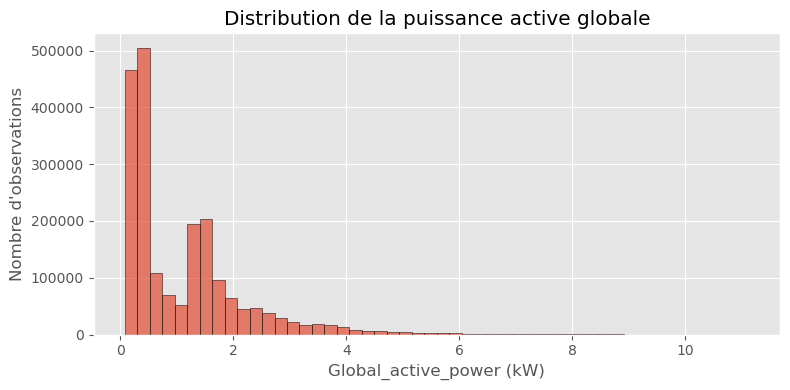

(array([466891, 505364, 108409,  68923,  51830, 194517, 203787,  95510,
         64202,  45728], dtype=int64),
 array([0.076  , 0.29692, 0.51784, 0.73876, 0.95968, 1.1806 , 1.40152,
        1.62244, 1.84336, 2.06428]))

In [11]:
import numpy as np
import matplotlib.pyplot as plt

series = raw_df["Global_active_power"].dropna()

# Calcul "brut" de l'histogramme (comptes + bornes)
counts, bin_edges = np.histogram(series, bins=50)

# Tracé de l'histogramme avec les mêmes paramètres
plt.figure(figsize=(8, 4))
plt.hist(series, bins=bin_edges, edgecolor="black", alpha=0.7)
plt.xlabel("Global_active_power (kW)")
plt.ylabel("Nombre d'observations")
plt.title("Distribution de la puissance active globale")
plt.tight_layout()
plt.show()

counts[:10], bin_edges[:10]

## Part de la distribution par grandes zones de puissance

In [12]:
# Définition de quelques zones de puissance (en kW)

# faible puissance
low_threshold = 1.0
# puissance moyenne
mid_threshold = 3.0

total = len(series)

low_mask = series < low_threshold
mid_mask = (series >= low_threshold) & (series < mid_threshold)
high_mask = series >= mid_threshold

low_pct = (low_mask.sum() / total) * 100
mid_pct = (mid_mask.sum() / total) * 100
high_pct = (high_mask.sum() / total) * 100

low_pct, mid_pct, high_pct

(56.640625, 37.21926725484073, 6.140107745159275)

La distribution de Global_active_power est très asymétrique à droite : la majorité des observations se concentrent dans les plus petites valeurs de puissance, avec une queue qui s'étend vers des puissances plus élevées. Ce type de forme est classique pour des données de consommation énergétique domestique, où le foyer fonctionne la plupart du temps à bas régime avec des pics ponctuels.

En analysant les comptes par classe de l'histogramme, on observe que :
- une proportion majoritaire des minutes de mesure correspond à une faible puissance (sous 1 kW) : c'est la situation normale du foyer, lorsque peu d'appareils fonctionnent en même temps ;
- une part significative mais plus réduite se situe dans une zone de puissance intermédiaire (entre environ 1 et 3 kW), qui correspond à des périodes où plusieurs équipements sont utilisés simultanément (cuisine, buanderie, etc.) ;
- seule une petite fraction du temps est passée en forte puissance, lorsque des appareils très consommateurs (chauffe-eau, gros électroménager, chauffage/climatisation) tournent en même temps.

Visuellement, le graphique montre donc :
- un bloc dense de barres collées près de zéro, témoignant d'une consommation modérée la plupart du temps ;
- puis des barres de plus en plus basses et espacées vers la droite, correspondant à des épisodes de forte consommation, beaucoup plus rares mais importants pour la gestion de la pointe de charge.

Cette lecture de la distribution sera utile ultérieurement pour la plateforme BI, par exemple pour définir des seuils de surveillance (puissance "normale" vs "élevée") et identifier les périodes de pointe sur les dashboards.

## Resampling journalier

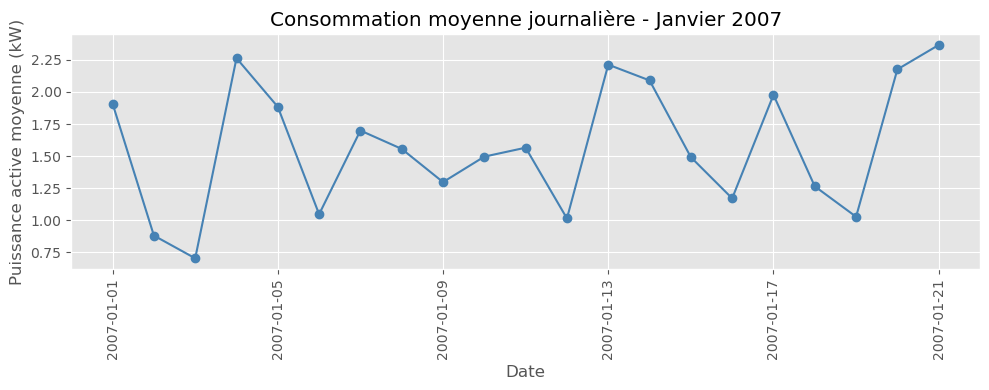

In [13]:
import matplotlib.pyplot as plt

# Calculer la moyenne journalière de la puissance active
daily_power = raw_df["Global_active_power"].resample("D").mean()

# Garder seulement 3 semaines pour une lecture claire
sample = daily_power["2007-01-01":"2007-01-21"]

# Tracer le graphique
plt.figure(figsize=(10, 4))
plt.plot(sample.index, sample.values, color="steelblue", marker="o")
plt.title("Consommation moyenne journalière - Janvier 2007")
plt.xlabel("Date")
plt.ylabel("Puissance active moyenne (kW)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Ce graphique montre l'évolution de la puissance active moyenne journalière sur les trois premières semaines de
janvier 2007, calculée en rééchantillonnant les données à la minute vers un pas de temps journalier (resample("D").mean()).

Observations clés :

- La courbe oscille entre environ 0,7 kW et 2,4 kW au fil des jours, avec une variabililté modérée d'un jour à l'autre.
- Le jour de plus faible consommation tombe le 3 janvier 2007, qui correspond à un mercredi (debut de semaine après le Nouvel An), possiblement une journée peu active ou une période de transition post-fêtes.
- Le jour de plus forte consommation est le 21 janvier 2007, un dimanche, ce qui est cohérent avec un usage résidentiel typique : les dimanches sont souvent des journées de présence à domicile, avec une cuisine, du chauffage et une buanderie plus sollicités.
- La variabilité journalière (écart-type ≈ 0,5 kW) indique des habitudes de consommation relativement régulières, interrompues par quelques pics, ce qui est attendu dans un foyer résidentiel standard.

## Conclusion

Cette phase d'exploration nous a permis de prendre en main le jeu de données UCI et de valider sa qualité avant d'entrer dans la phase de préparation.

Ce que nous avons établi :
- Le dataset contient 2 075 259 mesures à la minute sur 47 mois (décembre 2006 - novembre 2010), avec une couverture temporelle complète et aucun trou dans la grille de timestamps.
- Les 9 colonnes (puissance active/réactive, tension, intensité, 3 sous-compteurs) sont chargées avec les bons types numériques après conversion des ? en NaN.
- Les valeurs manquantes sont uniformément réparties sur toutes les colonnes de mesure à hauteur d'environ 1,25 % des lignes, un taux faible et gérable pour les transformations à venir.
- La distribution de la puissance active révèle un profil résidentiel typique : une majorité de minutes à faible puissance et des pics ponctuels.
- L'évolution journalière montre une variabilité réelle et cohérente, avec des jours de forte consommation (présence à domicile) et des jours plus calmes.

Le notebook 02_preparation_uci_power.ipynb abordera :
1. Le nettoyage des valeurs manquantes.
2. L'agrégation des données à l'heure et au jour.
3. L'export vers data/processed/ pour alimenter le pipeline Azure (ADF > Databricks > SQL).